# Лабораторная работа №5
## Построение нейронных сетей для Q-обучения (TensorFlow и PyTorch)




In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random


# Deep Q-Learning на TensorFlow


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Сеть Q(s,a)
tf_model = models.Sequential([
    layers.Input(shape=(state_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_actions, activation='linear')
])

optimizer = tf.keras.optimizers.Adam(1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()
gamma = 0.99


In [3]:
def tf_get_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    q_vals = tf_model(np.array([state]))[0]
    return int(tf.argmax(q_vals))


In [4]:
def tf_train_step(state, action, reward, next_state, done):
    state = np.array([state])
    next_state = np.array([next_state])

    with tf.GradientTape() as tape:
        q_values = tf_model(state)
        q_value = tf.reduce_sum(q_values * tf.one_hot([action], n_actions), axis=1)

        next_q_values = tf_model(next_state)
        next_q_value = tf.reduce_max(next_q_values, axis=1)

        # ВАЖНО: отключаем градиент через target (как в оригинальном DQN)
        target = reward + gamma * tf.stop_gradient(next_q_value) * (1 - int(done))

        loss = loss_fn(target, q_value)

    grads = tape.gradient(loss, tf_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, tf_model.trainable_variables))


[TF] Episode 0, mean reward: 10.00
[TF] Episode 50, mean reward: 13.80
[TF] Episode 100, mean reward: 14.08
[TF] Episode 150, mean reward: 14.46
[TF] Episode 200, mean reward: 17.14
[TF] Episode 250, mean reward: 30.74
[TF] Episode 300, mean reward: 33.94
[TF] Episode 350, mean reward: 65.68


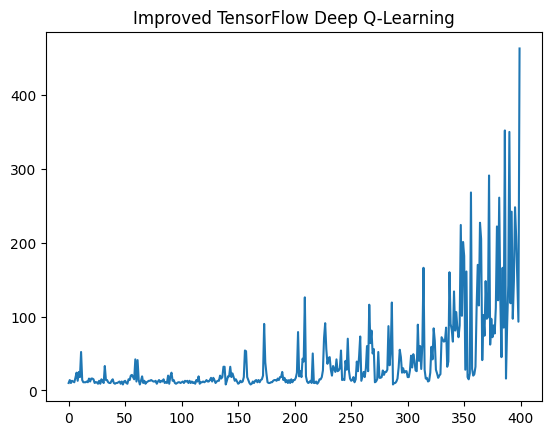

In [5]:
tf_rewards = []
epsilon = 0.5

for episode in range(400):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action = tf_get_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        tf_train_step(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(0.01, epsilon * 0.995)
    tf_rewards.append(total_reward)

    if episode % 50 == 0:
        print(f"[TF] Episode {episode}, mean reward: {np.mean(tf_rewards[-50:]):.2f}")

plt.plot(tf_rewards)
plt.title("Improved TensorFlow Deep Q-Learning")
plt.show()


# Deep Q-Learning на PyTorch


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)

torch_model = DQN(state_dim, n_actions)
optimizer_torch = optim.Adam(torch_model.parameters(), lr=1e-3)
loss_fn_torch = nn.MSELoss()


In [7]:
def torch_get_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        q_vals = torch_model(torch.FloatTensor(state))
    return int(torch.argmax(q_vals))


In [8]:
def torch_train_step(state, action, reward, next_state, done):
    state = torch.FloatTensor(state)
    next_state = torch.FloatTensor(next_state)

    q_values = torch_model(state)
    q_value = q_values[action]

    with torch.no_grad():
        next_q_values = torch_model(next_state)
        next_q_value = torch.max(next_q_values)
        target = reward + gamma * next_q_value * (1 - int(done))

    loss = loss_fn_torch(q_value, target)

    optimizer_torch.zero_grad()
    loss.backward()
    optimizer_torch.step()


[TORCH] Episode 0, mean reward: 10.00
[TORCH] Episode 50, mean reward: 13.50
[TORCH] Episode 100, mean reward: 16.36
[TORCH] Episode 150, mean reward: 49.66
[TORCH] Episode 200, mean reward: 59.78
[TORCH] Episode 250, mean reward: 72.66
[TORCH] Episode 300, mean reward: 131.06
[TORCH] Episode 350, mean reward: 142.38


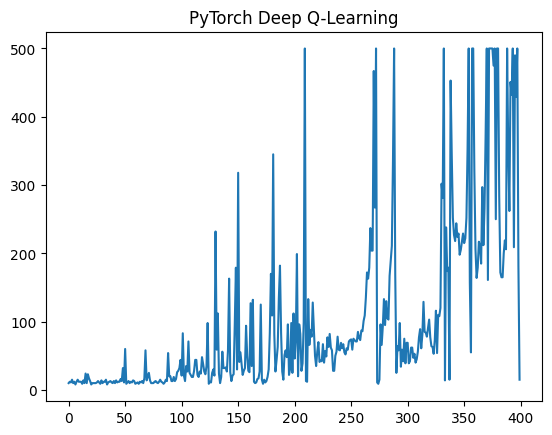

In [9]:
torch_rewards = []
epsilon = 0.5

for episode in range(400):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action = torch_get_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        torch_train_step(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(0.01, epsilon * 0.995)
    torch_rewards.append(total_reward)

    if episode % 50 == 0:
        print(f"[TORCH] Episode {episode}, mean reward: {np.mean(torch_rewards[-50:]):.2f}")

plt.plot(torch_rewards)
plt.title("PyTorch Deep Q-Learning")
plt.show()


# Анализ результатов
В работе реализован алгоритм Deep Q-Learning для среды CartPole.

1. Нейронная сеть аппроксимирует функцию Q(s,a).
2. Обучение выполняется по формуле TD-ошибки.
3. Используется epsilon-greedy стратегия для баланса исследования и эксплуатации.

В начале обучения награда низкая из-за случайных действий.
По мере уменьшения epsilon агент начинает чаще использовать выученную стратегию,
что приводит к росту средней награды.

Наблюдаются колебания награды — это характерно для Q-learning без replay buffer
и target network, так как веса сети обновляются на каждом шаге.

Обе реализации (TensorFlow и PyTorch) показывают схожую динамику обучения,
что подтверждает корректность реализации алгоритма.
